## Script to process multiple years using a Fourier Series Fit to the Temp Time Series, and measure the gradient of the curve at the start and end of summer

### edit array of years to process below - roughly XXX hours for YYY years processing time 

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

import scipy.stats as stats
from sklearn import linear_model
import statsmodels.api as sm
import seaborn as sns

# to get rid of runtime warnings when OLS fits hit a divide by zero - handled by setting R2 and p-vals appropriately
import warnings
warnings.filterwarnings('ignore')

In [34]:


###################
# helper functions
###################
def GradientStatsFourier(temp_data, temp_data_next, threshold):
    '''

    Function that uses the input 75th percentile temperature in K to identify the summer from a time series of temperatures.
    Input data should already be set to 365 days.

    Args:
        temp_data: xarray of temperature data for a single grid cell for the year of interest
        temp_data_next: xarray of temperature data for a single grid cell for the following year (for SH summers)
        threshold: xarray for the 75th percentile threshold to use
        
    Returns:
        start day: DOY that daily mean t2m (from smoothed Fourier fit) first crossed above threshold (75th percentile)
        end day: DOY that daily mean t2m (from smoothed Fourier fit) first crossed below threshold (75th percentile) 
        grad_start: the gradient (slope) of the fourier fit at on the start day of summer
        grad_end: the gradient (slope) of the fourier fit on the end day of summer
        
    Example:
        start_day, last_day, grad_start, grad_end = GradientStatsFourier(temps, temps_next, thresh)

    '''

    # default values
    start_f = 0 
    end_f = 0
    grad_start_f = 0 
    grad_end_f = 0 
    summer_length_f = 0

    # split method based on NH or SH

    ######
    # Northern Hemisphere (uses current year only)
    if temp_data.lat.values >= 0:
        # extract DOY and T2m values for those days
        x1 = temp_data.time.dt.dayofyear.values
        y1 = temp_data.values

        # Fourier fit, up to 4th harmonic (mean + 3 more) as in Weller et al 2020
        ymean = np.mean(y1)
        y_norm = y1 - ymean
        # perform DFT of temp data
        coef = fft(y_norm)
        # low-pass filter: retain only the mean and the first three harmonics, set all other frequencies to zero
        # help from https://kls2177.github.io/Climate-and-Geophysical-Data-Analysis/chapters/Week6/filtering_in_freq2.html
        Z_lp = np.copy(coef)
        Z_lp[4:-3:] = 0.0  # we have to set both the positive and negative frequencies to zero
        # apply inverse fourier transform to convert back to time domain (just want the real part)
        y_norm_lp = np.real(np.fft.ifft(Z_lp))

        # add back in the original mean temp
        y_lp = y_norm_lp + ymean

        # RMSE for Fourier fit
        rmse = np.sqrt(np.sum((y1-y_lp)**2)/365.0)

        # create some x values for plotting fits
        x_values = np.linspace(min(x1), max(x1), 365)
    
        ### DETERMINE START AND END FOR FOURIER and Calc Gradient
        # use fit to get stats
        summer_length_f = np.count_nonzero(y_lp >= threshold.values)
        summer_days_f = np.where(y_lp >= threshold.values)[0]
        grad_fourier = np.gradient(y_lp)

        # deal with case where there is no summer - rare but can happen
        if summer_length_f == 0:
            start_f = np.nan
            end_f = np.nan
            grad_start_f = np.nan 
            grad_end_f = np.nan 

        else:
            start_f = int(x_values[min(summer_days_f)])
            grad_start_f = grad_fourier[start_f]
            
            # end day comes after first day so find next crossing of poly fit
            # this is to be careful to not count until the end of a double crossing
            end_window = np.where((y_lp[start_f:365]) < threshold.values)

            # if it does cross back below threshold before the end of the "year"
            if np.count_nonzero(end_window):
                end_f = end_window[0][0] + start_f
                grad_end_f = grad_fourier[end_f]

            # otherwise it never crosses back below threshold for the "year"
            # so the last day is day 365 (index = 364)
            else:
                end_f = 365
                grad_end_f = grad_fourier[end_f-1] 
            # end_f = int(x_values[max(summer_days_f)])

            # # get gradient at start/end of summer
            # grad_start_f = grad_fourier[start_f]
            # grad_end_f = grad_fourier[end_f]

                
    
    ######
    # Southern Hemisphere (uses current year and following year)
    else: 
        # concat both years
        ds_two = xr.concat([temp_data, temp_data_next], dim="time")

        # get the current year for slicing
        input_year = temp_data.time.dt.year.values[0]

        # select July 1 - June 30 across the two years to do fit
        startdate = str(input_year)+'-07-01' # 182nd day of a normal year
        enddate = str(input_year+1)+'-06-30'
        sh_yr = ds_two.sel(time=slice(startdate,enddate))
        
        # DOY (relative to July 1) and T2m values for those days
        x1 = np.arange(1,len(sh_yr.time)+1) 
        y1 = sh_yr.values
        
        # Fourier fit, up to 4th harmonic (mean + 3 more) as in Weller et al 2020
        ymean = np.mean(y1)
        y_norm = y1 - ymean
        # perform DFT of temp data
        coef = fft(y_norm)
        # low-pass filter: retain only the mean and the first three harmonics, set all other frequencies to zero
        # help from https://kls2177.github.io/Climate-and-Geophysical-Data-Analysis/chapters/Week6/filtering_in_freq2.html
        Z_lp = np.copy(coef)
        Z_lp[4:-3:] = 0.0  # we have to set both the positive and negative frequencies to zero
        # apply inverse fourier transform to convert back to time domain (just want the real part)
        y_norm_lp = np.real(np.fft.ifft(Z_lp))

        # add back in the original mean temp
        y_lp = y_norm_lp + ymean

        # RMSE for Fourier fit
        rmse = np.sqrt(np.sum((y1-y_lp)**2)/365.0)
        
        # create some x values for plotting polynomial fit
        x_values = np.linspace(min(x1), max(x1), 365) 

        ### DETERMINE START AND END FOR FOURIER and Calc Gradient
        # use fit to get stats
        summer_length_f = np.count_nonzero(y_lp >= threshold.values)
        summer_days_f = np.where(y_lp >= threshold.values)[0]
        grad_fourier = np.gradient(y_lp)

        # deal with case where there is no summer - rare but can happen
        if summer_length_f == 0:
            start_f = np.nan
            end_f = np.nan
            grad_start_f = np.nan 
            grad_end_f = np.nan 

        else:
            start_f = int(x_values[min(summer_days_f)])
            grad_start_f = grad_fourier[start_f]
            
            # end day comes after first day so find next crossing of poly fit
            # this is to be careful to not count until the end of a double crossing
            end_window = np.where((y_lp[start_f:365]) < threshold.values)

            # if it does cross back below threshold before the end of the "year"
            if np.count_nonzero(end_window):
                end_f = end_window[0][0] + start_f
                grad_end_f = grad_fourier[end_f]

            # otherwise it never crosses back below threshold for the "year"
            # so the last day is day 365 (index = 364)
            else:
                end_f = 365
                grad_end_f = grad_fourier[end_f-1] 

            #end_f = int(x_values[max(summer_days_f)])
                
    # returns all floats since start and end could be nan
    return float(start_f), float(end_f), float(grad_start_f), float(grad_end_f)



# a function that takes in a dataset of global t2m values and if it is a leap year averages
# the temps on Feb 28 & Feb 29, then drops Feb 29 to ensure the year has 365 days
def HandleLeapYears(input_ds):
    '''

    Function that takes the mean of Feb 28 & Feb 29 (if it exists) and returns an xarray Dataset that has 365 days
    where Feb 28 will now have a t2m value that is the mean of Feb 28 & Feb 29

    Args:
        input_ds: the data set containing a single year of data that may need adjusting for leap year
        
    Returns:
        output_ds
        
    Example:
        no_leap_ds = HandleLeapYears(input_ds)

    '''
    

    # check if a leap year
    if(input_ds.time.dt.is_leap_year[0].values):
        
        # make deep copy
        output_ds = input_ds.copy(deep=True)
        
        # get mean of Feb 28 (time index 58) & Feb 29 (time index 59) for each grid cell and overwrite Feb 28 with it
        mean_dat = output_ds.t2m[58:60].mean(dim='time', skipna=True, keep_attrs=True)
        output_ds.t2m[58] = mean_dat
        
        # drop Feb 29
        output_ds = output_ds.convert_calendar('noleap', use_cftime=None)

        # ensure time is datetime64
        output_ds["time"] = output_ds.time.dt.strftime('%Y-%m-%d')
        output_ds['time'] = pd.to_datetime(output_ds['time'])

        # return the new dataset 
        return output_ds
    else:
        return input_ds
    

In [49]:
# latitude & longitude ranges for NH and SH midlatitudes so they will be easy to adjust
nh_min = 23.5
nh_max = 70
sh_min = -23.5
sh_max = -70

### Load threshold values for finding summer

In [3]:
# get baseline (again) to keep code blocks together
file_path = '../../../Data/ERA5-global/Baseline/computed_1961-1990-full_75th.nc'
c_75 = xr.open_dataarray(file_path)
c_75.values


array([[236.4370575 , 236.4370575 , 236.4370575 , ..., 236.4370575 ,
        236.4370575 , 236.4370575 ],
       [236.18743896, 236.1893158 , 236.19142151, ..., 236.18388367,
        236.18530273, 236.18659973],
       [235.91021729, 235.9200592 , 235.92704773, ..., 235.88049316,
        235.8903656 , 235.90020752],
       ...,
       [270.7281189 , 270.72640991, 270.72720337, ..., 270.73239136,
        270.73184204, 270.73007202],
       [270.74356079, 270.74273682, 270.74200439, ..., 270.74594116,
        270.74508667, 270.74420166],
       [270.7550354 , 270.7550354 , 270.7550354 , ..., 270.7550354 ,
        270.7550354 , 270.7550354 ]])

### Test it out on Vancouver

In [4]:
# grid parameters for looping
num_lat = 721
num_lon = 1440

loop_lats = c_75.lat.values[:num_lat]
loop_lons = c_75.lon.values[:num_lon]

In [40]:
# testing mean temp addition
input_year = 2023

# get this year and next year's daily mean t2m data
if input_year <= 1990:
    file_path = '../../../Data/ERA5-global/Baseline/' + str(input_year) + '/*.nc'
else:
    file_path = '../../../Data/ERA5-global/Analysis/' + str(input_year) + '/*.nc'
ds = xr.open_mfdataset(file_path)

if input_year+1 <= 1990:
    file_path_next = '../../../Data/ERA5-global/Baseline/' + str(input_year+1) + '/*.nc'
else:
    file_path_next = '../../../Data/ERA5-global/Analysis/' + str(input_year+1) + '/*.nc'
dsnext = xr.open_mfdataset(file_path_next)

# remove leap day by averaging Feb 28 & 29 together before dropping Feb 29
ds = HandleLeapYears(ds)
dsnext = HandleLeapYears(dsnext)

# load into memory to speed up the summer stats processing
ds.load()
dsnext.load()

#test for Vancouver
input_lat = 49.246
input_lon = -123.116
curr = ds.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
nxt = dsnext.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
thresh = c_75.sel(lat=input_lat, lon=input_lon, method="nearest")
start_day, last_day, grad_start, grad_end = GradientStatsFourier(curr, nxt, thresh)
start_day, last_day, grad_start, grad_end

(142.0, 266.0, 0.133148193359375, -0.1600799560546875)

In [ ]:
#(142.0, 266.0, 0.133148193359375, -0.1600799560546875)

In [41]:
# test for Sydney
input_lat = -33 - 52/60 - 4/3600
input_lon = 151.25
curr = ds.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
nxt = dsnext.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
thresh = c_75.sel(lat=input_lat, lon=input_lon, method="nearest")
start_day, last_day, grad_start, grad_end = GradientStatsFourier(curr, nxt, thresh)
start_day, last_day, grad_start, grad_end

(145.0, 275.0, 0.059051513671875, -0.09149169921875)

## ********** NEED to run all years now and output file for later analysis

## Main Loop: loop through multiple years to generate summer stats

In [56]:
# process_yrs = [1990,1991,1992,1993, 1994, 1995, 1996, 1997, 1998, 1999, 2002, 2004, 2005, 2006, 2007, 2008,
#               2009, 2010, 2011, 2012, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
process_yrs = np.arange(1961, 1985,1)
missing = np.arange(1986,1990,1)

process_yrs = np.append(process_yrs,missing)
process_yrs

array([1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1986, 1987, 1988, 1989])

In [ ]:
%%time

# Runtime: 19 min for 1 year
# 1 hr 50 min for 6 years

# loop thru the years in the defined array above
for input_year in process_yrs:

    # get this year and next year's daily mean t2m data
    if input_year <= 1990:
        file_path = '../../../Data/ERA5-global/Baseline/' + str(input_year) + '/*.nc'
    else:
        file_path = '../../../Data/ERA5-global/Analysis/' + str(input_year) + '/*.nc'
    ds = xr.open_mfdataset(file_path)

    if input_year+1 <= 1990:
        file_path_next = '../../../Data/ERA5-global/Baseline/' + str(input_year+1) + '/*.nc'
    else:
        file_path_next = '../../../Data/ERA5-global/Analysis/' + str(input_year+1) + '/*.nc'
    dsnext = xr.open_mfdataset(file_path_next)

    # remove leap day by averaging Feb 28 & 29 together before dropping Feb 29
    ds = HandleLeapYears(ds)
    dsnext = HandleLeapYears(dsnext)

    # load into memory to speed up the summer stats processing
    ds.load()
    dsnext.load()

    # empty data arrays for summer stats
    summerstart = xr.DataArray(np.zeros((num_lat,num_lon)), 
                               coords=[loop_lats, loop_lons], 
                               dims=['lat','lon'])
    summerend = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    start_grad_f = xr.DataArray(np.zeros((num_lat,num_lon)), 
                                coords=[loop_lats, loop_lons], 
                                dims=['lat','lon'])
    
    end_grad_f = xr.DataArray(np.zeros((num_lat,num_lon)), 
                                coords=[loop_lats, loop_lons], 
                                dims=['lat','lon'])
    
    # add attributes
    summerstart.attrs["long_name"] = "Start day of summer for the year (DOY in [1,365])"
    summerstart.attrs["units"] = "Day of year"
    
    summerend.attrs["long_name"] = "Last day of summer for the year (DOY in [1,365])"
    summerend.attrs["units"] = "Day of year"
    
    start_grad_f.attrs["long_name"] = "Gradient of Fourier Fit at Summer Start"
    start_grad_f.attrs["units"] = "Deg/Day"
    
    end_grad_f.attrs["long_name"] = "Gradient of Fourier Fit at Summer End"
    end_grad_f.attrs["units"] = "Deg/Day"
    

    # loop through all of the lat,lon of interest
    for input_lat in loop_lats:
        for input_lon in loop_lons:
            # get threshold from c_75
            thresh = c_75.sel(lat=input_lat,lon=input_lon)
    
            # all the temps for that grid cell over time for this year and next (for SH)
            curr = ds.t2m.sel(lat=input_lat,lon=input_lon) 
            nxt = dsnext.t2m.sel(lat=input_lat, lon=input_lon)
    
            # build summer stats for the grid cell and produce the plot if desired (currently False)
            start_day, last_day, grad_start, grad_end = GradientStatsFourier(curr, nxt, thresh)
            
            # xarray requires strange indexing in order to replace values by coordinate
            summerstart.loc[input_lat, input_lon] = start_day
            summerend.loc[input_lat, input_lon] = last_day
            start_grad_f.loc[input_lat, input_lon] = grad_start
            end_grad_f.loc[input_lat, input_lon] = grad_end
            
            

    # save it out
    sum_ds = xr.Dataset(data_vars={'SummerStart':summerstart,
                               'SummerEnd':summerend,
                                'GradientSummStartFourier':start_grad_f,
                                'GradientSummEndFourier':end_grad_f})
    
    output_path = '../../../Data/ERA5-global/Analysis/New-Fourier/Gradients/'+str(input_year)+'_summer_gradient_stats.nc'
    sum_ds.to_netcdf(output_path)

    # plots for the year
    ##############
    # Global summer mean temp for the year
    fig = plt.figure(figsize=(16,8))
    
    ax1 = fig.add_subplot(1,2,1, projection=ccrs.Robinson(central_longitude=0))
    # assign axis and def projection to use
    #ax1 = plt.axes(projection=ccrs.Robinson(central_longitude=0))
    
    # add coastlines and grid
    ax1.coastlines()
    ax1.gridlines()
    
    sum_ds.GradientSummStartFourier.where((sum_ds.lat >= nh_min) | (sum_ds.lat <= sh_min)).plot(
        ax=ax1,
        transform=ccrs.PlateCarree(), # assign map projection
        vmin=-0.3,
        vmax=0.3, # define range to include an entire year
        cmap="coolwarm",#"YlOrRd"#cmap="coolwarm"
        cbar_kwargs={'shrink': 0.5}
    )
    ax1.set_title("Gradient at Start of Summer for "+str(input_year))#+" using 1961-1990 baseline")
    
    ax2 = fig.add_subplot(1,2,2, projection=ccrs.Robinson(central_longitude=0))
    # assign axis and def projection to use
    #ax2 = plt.axes()
    
    # add coastlines and grid
    ax2.coastlines()
    ax2.gridlines()
    
    sum_ds.GradientSummEndFourier.where((sum_ds.lat >= nh_min) | (sum_ds.lat <= sh_min)).plot(
        ax=ax2,
        transform=ccrs.PlateCarree(), # assign map projection
        vmin=-0.3,
        vmax=0.3, # define range to include an entire year
        cmap="coolwarm",#"YlOrRd"#cmap="coolwarm"
        cbar_kwargs={'shrink': 0.5}
    )
    ax2.set_title("Gradient at End of Summer for "+str(input_year))#+" using 1961-1990 baseline")
    #plt.tight_layout()
    plt.show()



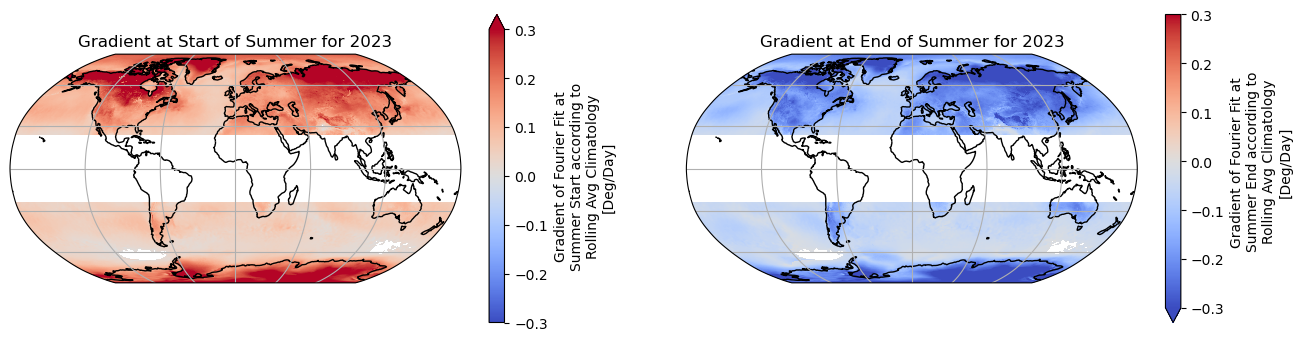

CPU times: user 19.3 s, sys: 248 ms, total: 19.6 s
Wall time: 19.6 s


In [53]:
%%time

fig = plt.figure(figsize=(16,8))

ax1 = fig.add_subplot(1,2,1, projection=ccrs.Robinson(central_longitude=0))
# assign axis and def projection to use
#ax1 = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax1.coastlines()
ax1.gridlines()

sum_ds.GradientSummStartFourier.where((sum_ds.lat >= nh_min) | (sum_ds.lat <= sh_min)).plot(
    ax=ax1,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=-0.3,
    vmax=0.3, # define range to include an entire year
    cmap="coolwarm",#"YlOrRd"#cmap="coolwarm"
    cbar_kwargs={'shrink': 0.5}
)
ax1.set_title("Gradient at Start of Summer for "+str(input_year))#+" using 1961-1990 baseline")

ax2 = fig.add_subplot(1,2,2, projection=ccrs.Robinson(central_longitude=0))
# assign axis and def projection to use
#ax2 = plt.axes()

# add coastlines and grid
ax2.coastlines()
ax2.gridlines()

sum_ds.GradientSummEndFourier.where((sum_ds.lat >= nh_min) | (sum_ds.lat <= sh_min)).plot(
    ax=ax2,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=-0.3,
    vmax=0.3, # define range to include an entire year
    cmap="coolwarm",#"YlOrRd"#cmap="coolwarm"
    cbar_kwargs={'shrink': 0.5}
)
ax2.set_title("Gradient at End of Summer for "+str(input_year))#+" using 1961-1990 baseline")
#plt.tight_layout()
plt.show()

33.166666666666664

# ********** Once we have all years processed for gradients, then compile them into a single file with the coastal flag and LSM

## Load LSM for filtering

In [4]:
file_path = '../../../Data/ERA5-global/ERA5-2023-09-01-CoordFixed-LSM.nc'
ds_lsm = xr.open_dataset(file_path)
ds_lsm

<xarray.Dataset> Size: 8MB
Dimensions:  (lat: 721, lon: 1440)
Coordinates:
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    lsm      (lat, lon) float64 8MB ...

## Pull in the coastal margins for use in data processing and write out full 1961-2023 Summer Stats for Fourier fit data

In [8]:
# write those results out for later use
input_path = '../../../Data/ERA5-global/ERA5-2023-09-01-CoordFixed-CoastalMargins.nc'
results_ds = xr.open_dataset(input_path)



In [12]:
results_ds

<xarray.Dataset> Size: 1MB
Dimensions:  (lat: 721, lon: 1440)
Coordinates:
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    Coastal  (lat, lon) bool 1MB ...

## * Build and write out the full data set from Fourier fits including the coastal margin boolean

In [13]:
%%time

# takes ~4 min to load

# start with one year and lsm then coastal and add a coordinate for the year
year = 1961
input_path = '../../../Data/ERA5-global/Analysis/New-Fourier/Gradients/'+str(year)+'_summer_gradient_stats.nc'
ds_base = xr.open_dataset(input_path)
ds_base = ds_base.merge(ds_lsm) # add lsm
ds_base = ds_base.merge(results_ds) # add coastal flag
ds_base = ds_base.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))

# loop thru remaining years and also add time coord
input_years = np.arange(1962,2024,1)

for year in input_years:
    input_path = '../../../Data/ERA5-global/Analysis/New-Fourier/Gradients/'+str(year)+'_summer_gradient_stats.nc'
    ds_i = xr.open_dataset(input_path)
    ds_i = ds_i.merge(ds_lsm)
    ds_i = ds_i.merge(results_ds)
    ds_i = ds_i.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))
    ds_base = ds_base.merge(ds_i)

ds_base

CPU times: user 1min 33s, sys: 2min 18s, total: 3min 51s
Wall time: 4min 21s


<xarray.Dataset> Size: 6GB
Dimensions:       (lat: 721, lon: 1440, time: 63)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 504B 1961-01-01 ... 2023-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 523MB 136.0 136.0 ... 162.0 162.0
    SummerEnd     (time, lat, lon) float64 523MB 222.0 222.0 ... 244.0 244.0
    SummerTmax    (time, lat, lon) float64 523MB 179.0 179.0 ... 231.0 231.0
    SummerHeat    (time, lat, lon) float64 523MB 389.4 389.4 ... 233.5 233.5
    SummerLength  (time, lat, lon) float64 523MB 87.0 87.0 87.0 ... 83.0 83.0
    SummerRMSE    (time, lat, lon) float64 523MB 4.261 4.261 ... 3.041 3.041
    SummerR2      (time, lat, lon) float64 523MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerMeanT   (time, lat, lon) float64 523MB 240.7 240.7 ... 273.6 273.6
    SummerMeanHS  (time, lat, lon) float64 523MB 4.993 4.993 ... 2.813 2.813
    lsm           (time, lat, lon) float64 523MB 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0
    Coastal       (time, lat, lon) float64 523MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0

In [14]:
# re-add attributes which get lost on merge apparently
ds_base.SummerStart.attrs["long_name"] = "Start day of summer for the year (DOY in [1,365])"
ds_base.SummerStart.attrs["units"] = "Day of year"

ds_base.SummerEnd.attrs["long_name"] = "Last day of summer for the year (DOY in [1,365])"
ds_base.SummerEnd.attrs["units"] = "Day of year"

ds_base.GradientSummStartFourier.attrs["long_name"] = "Gradient of Fourier Fit at Summer Start"
ds_base.GradientSummStartFourier.attrs["units"] = "Deg/Day"
    
ds_base.GradientSummEndFourier.attrs["long_name"] = "Gradient of Fourier Fit at Summer End"
ds_base.GradientSummEndFourier.attrs["units"] = "Deg/Day"

###
### also cast the Coastal as boolean?
###
ds_base.Coastal.values = ds_base.Coastal.values.astype(bool)
ds_base.Coastal.attrs["long_name"] = "Boolean value for whether a >30% land cell has at least one >80% water neighbor"
ds_base.Coastal.attrs["units"] = "true/false"

ds_base

<xarray.Dataset> Size: 5GB
Dimensions:       (lat: 721, lon: 1440, time: 63)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 504B 1961-01-01 ... 2023-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 523MB 136.0 136.0 ... 162.0 162.0
    SummerEnd     (time, lat, lon) float64 523MB 222.0 222.0 ... 244.0 244.0
    SummerTmax    (time, lat, lon) float64 523MB 179.0 179.0 ... 231.0 231.0
    SummerHeat    (time, lat, lon) float64 523MB 389.4 389.4 ... 233.5 233.5
    SummerLength  (time, lat, lon) float64 523MB 87.0 87.0 87.0 ... 83.0 83.0
    SummerRMSE    (time, lat, lon) float64 523MB 4.261 4.261 ... 3.041 3.041
    SummerR2      (time, lat, lon) float64 523MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerMeanT   (time, lat, lon) float64 523MB 240.7 240.7 ... 273.6 273.6
    SummerMeanHS  (time, lat, lon) float64 523MB 4.993 4.993 ... 2.813 2.813
    lsm           (time, lat, lon) float64 523MB 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0
    Coastal       (time, lat, lon) bool 65MB False False False ... False False

In [15]:
# write out complete dataset with LSM and Coastal flags
output_path = '../../../Data/ERA5-global/Analysis/New-Fourier/1961-2023_ALL_summer_gradient_stats.nc'
ds_base.to_netcdf(output_path)


In [54]:
! ls -al "../../../Data/ERA5-global/Analysis/New-Fourier/Gradients"

total 2273040
drwxr-xr-x@ 37 tedscott  staff      1184 Mar 26 05:32 .
drwxr-xr-x@ 81 tedscott  staff      2592 Mar 24 12:39 ..
-rw-r--r--@  1 tedscott  staff  33249733 Mar 25 09:46 1985_summer_gradient_stats.nc
-rw-r--r--@  1 tedscott  staff  33249733 Mar 25 10:29 1990_summer_gradient_stats.nc
-rw-r--r--@  1 tedscott  staff  33249733 Mar 25 10:48 1991_summer_gradient_stats.nc
-rw-r--r--@  1 tedscott  staff  33249733 Mar 25 11:06 1992_summer_gradient_stats.nc
-rw-r--r--@  1 tedscott  staff  33249733 Mar 25 11:25 1993_summer_gradient_stats.nc
-rw-r--r--@  1 tedscott  staff  33249733 Mar 25 11:44 1994_summer_gradient_stats.nc
-rw-r--r--@  1 tedscott  staff  33249733 Mar 25 12:03 1995_summer_gradient_stats.nc
-rw-r--r--@  1 tedscott  staff  33249733 Mar 25 13:55 1996_summer_gradient_stats.nc
-rw-r--r--@  1 tedscott  staff  33249733 Mar 25 15:38 1997_summer_gradient_stats.nc
-rw-r--r--@  1 tedscott  staff  33249733 Mar 25 16:17 1998_summer_gradient_stats.nc
-rw-r--r--@  1 tedscott  staff  3